## 1 - INSTALACION Y DEPENDENCIAS

In [ ]:
pip install fitter

In [ ]:
from fitter import Fitter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2 - VALIDACION CSV

In [ ]:
# Ruta al CSV dentro de Drive
RUTA_CSV = '/content/drive/MyDrive/pedidos_delivery.csv'

df_delivery = pd.read_csv(RUTA_CSV, parse_dates=['fecha_hora'])
print(f'Registros cargados : {len(df_delivery):,}')
print(f'Columnas           : {df_delivery.columns.tolist()}')
print(f'Período            : {df_delivery["fecha_hora"].min()} → {df_delivery["fecha_hora"].max()}')
df_delivery.head(10)

Registros cargados : 5,686
Columnas           : ['id_pedido', 'fecha_hora', 'zona_destino', 'distancia_km', 'valor_pedido', 'clima', 'dia_semana', 'prioridad']
Período            : 2024-03-01 00:19:06 → 2024-04-29 23:31:16


,id_pedido,fecha_hora,zona_destino,distancia_km,valor_pedido,clima,dia_semana,prioridad
0,1,2024-03-01 00:19:06,Parque Centenario,1.26,18700,normal,viernes,normal
1,2,2024-03-01 00:27:42,Colegiales,1.80,14800,normal,viernes,express
2,3,2024-03-01 00:32:47,Colegiales,2.10,7000,normal,viernes,normal
3,4,2024-03-01 00:35:44,Caballito,2.52,18500,normal,viernes,normal
4,5,2024-03-01 00:38:16,Villa Crespo,0.49,10200,normal,viernes,normal
5,6,2024-03-01 00:42:43,Almagro,1.03,23100,normal,viernes,normal
6,7,2024-03-01 00:47:36,Once,1.62,20200,normal,viernes,normal
7,8,2024-03-01 00:53:44,Villa Ortuzar,1.18,9200,normal,viernes,express
8,9,2024-03-01 01:02:19,Palermo,2.33,12100,normal,viernes,normal
9,10,2024-03-01 01:24:45,Parque Centenario,1.17,20300,normal,viernes,express


# 3 - Transformacion datos

In [ ]:
# Filtramos el dataset para que tome solo los pedidos menores a 2km
df_delivery = df_delivery[df_delivery["distancia_km"] <= 2]

# Transformacion fecha a datetime
df_delivery['fecha_hora_datetime'] = pd.to_datetime(df_delivery['fecha_hora'])


# Calculo intervalo entre arribos
df_delivery['IA'] = df_delivery['fecha_hora_datetime'].diff()
df_delivery['IA_segundos'] = df_delivery['IA'].dt.total_seconds()
df_delivery['IA_minutos']  = df_delivery['IA_segundos'] / 60

# Calculo velocidad
VELOCIDAD_KMH = 18
df_delivery['TA_minutos'] = ((df_delivery['distancia_km'] / VELOCIDAD_KMH) * 60) * 2

### IA según horario

In [ ]:
# Obtener hora
df_delivery['hora'] = df_delivery['fecha_hora_datetime'].dt.hour

# Separar por horario
df_manana = df_delivery[(df_delivery['hora'] >= 9) & (df_delivery['hora'] < 12)].copy()

df_mediodia = df_delivery[(df_delivery['hora'] >= 12) & (df_delivery['hora'] < 16)].copy()

df_tarde = df_delivery[(df_delivery['hora'] >= 16) & (df_delivery['hora'] < 20)].copy()

df_noche = df_delivery[(df_delivery['hora'] >= 20) | (df_delivery['hora'] < 2)].copy()

# Calculo intervalo entre arrivos para cada uno
df_manana['IA'] = df_manana['fecha_hora_datetime'].diff()
df_manana['IA_segundos'] = df_manana['IA'].dt.total_seconds()
df_manana['IA_minutos']  = df_manana['IA_segundos'] / 60

df_mediodia['IA'] = df_mediodia['fecha_hora_datetime'].diff()
df_mediodia['IA_segundos'] = df_mediodia['IA'].dt.total_seconds()
df_mediodia['IA_minutos']  = df_mediodia['IA_segundos'] / 60

df_tarde['IA'] = df_tarde['fecha_hora_datetime'].diff()
df_tarde['IA_segundos'] = df_tarde['IA'].dt.total_seconds()
df_tarde['IA_minutos']  = df_tarde['IA_segundos'] / 60

df_noche['IA'] = df_noche['fecha_hora_datetime'].diff()
df_noche['IA_segundos'] = df_noche['IA'].dt.total_seconds()
df_noche['IA_minutos']  = df_noche['IA_segundos'] / 60

# 4 - Filtro TA e IA

In [ ]:
histograma_TA_amplio = df_delivery[df_delivery['TA_minutos'] > 2]
histograma_TA_primer_minuto = df_delivery[df_delivery['TA_minutos'] <= 2]
histograma_IA = df_delivery[df_delivery['IA_minutos'] < 60]

In [ ]:
histograma_IA_manana = df_manana[df_manana['IA_minutos'] < 60]
histograma_IA_mediodia = df_mediodia[df_mediodia['IA_minutos'] < 60]
histograma_IA_tarde = df_tarde[df_tarde['IA_minutos'] < 60]
histograma_IA_noche = df_noche[df_noche['IA_minutos'] < 60]

# 5 - Histogramas

array([[<Axes: title={'center': 'valor_pedido'}>]], dtype=object)

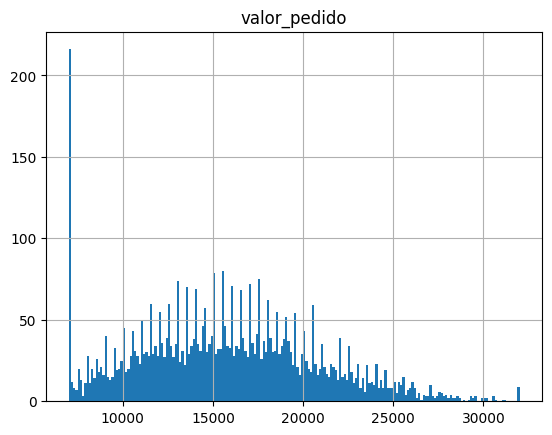

In [ ]:
df_delivery.hist('valor_pedido', bins=200)

array([[<Axes: title={'center': 'TA_minutos'}>]], dtype=object)

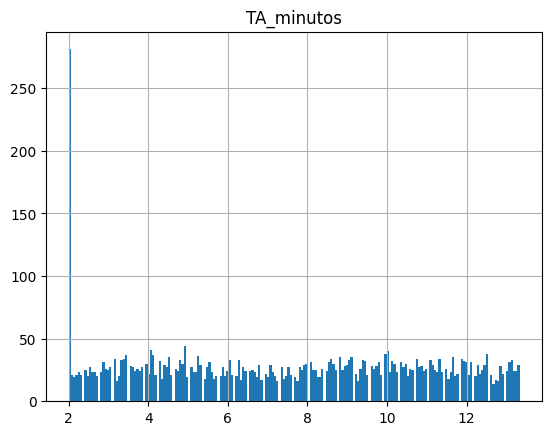

In [ ]:
df_delivery.hist('TA_minutos', bins=200)

array([[<Axes: title={'center': 'IA_minutos'}>]], dtype=object)

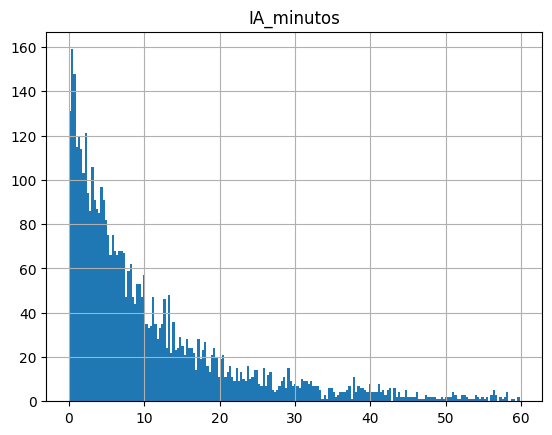

In [ ]:
histograma_IA.hist('IA_minutos', bins=200)

array([[<Axes: title={'center': 'IA_minutos'}>]], dtype=object)

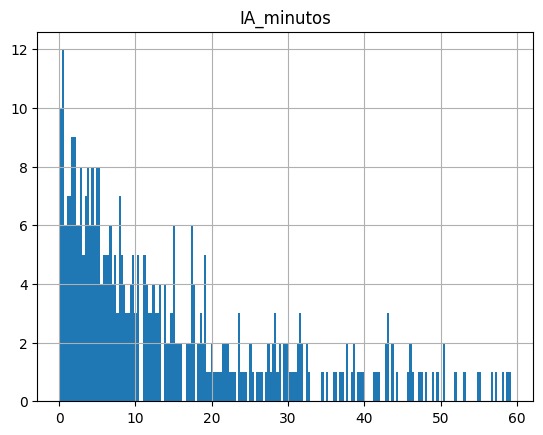

In [ ]:
histograma_IA_manana.hist('IA_minutos',bins=200)

array([[<Axes: title={'center': 'IA_minutos'}>]], dtype=object)

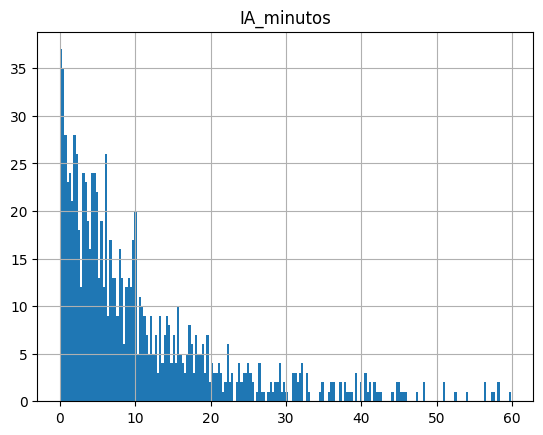

In [ ]:
histograma_IA_mediodia.hist('IA_minutos',bins=200)

array([[<Axes: title={'center': 'IA_minutos'}>]], dtype=object)

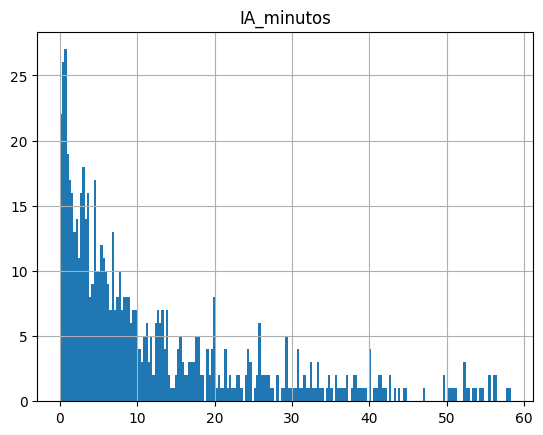

In [ ]:
histograma_IA_tarde.hist('IA_minutos',bins=200)

array([[<Axes: title={'center': 'IA_minutos'}>]], dtype=object)

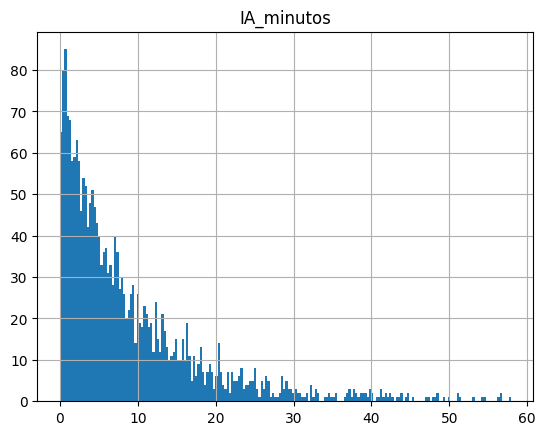

In [ ]:
histograma_IA_noche.hist('IA_minutos',bins=200)

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
levy_stable,4.260371e-08,93231.229540,93257.041438,0.076964,0.048341,5.821770e-10
rice,4.294369e-08,92931.105799,92950.464723,0.081037,0.029397,5.919689e-04
loggamma,4.313709e-08,93222.436261,93241.795184,0.075080,0.044169,2.184868e-08
rdist,4.321040e-08,93186.111622,93205.470545,0.072909,0.038287,2.078926e-06
tukeylambda,4.322211e-08,93190.862905,93210.221828,0.072989,0.038844,1.389112e-06
gennorm,4.337399e-08,93177.410462,93196.769386,0.073614,0.036569,6.961125e-06
ncx2,4.339443e-08,93132.694139,93158.506038,0.078447,0.032313,1.091998e-04
recipinvgauss,4.339522e-08,93171.999367,93191.358291,0.076435,NaN,NaN
norm,4.346445e-08,93205.429945,93218.335895,0.075462,0.040529,3.956342e-07
t,4.346446e-08,93207.430450,93226.789374,0.075462,0.040529,3.956232e-07


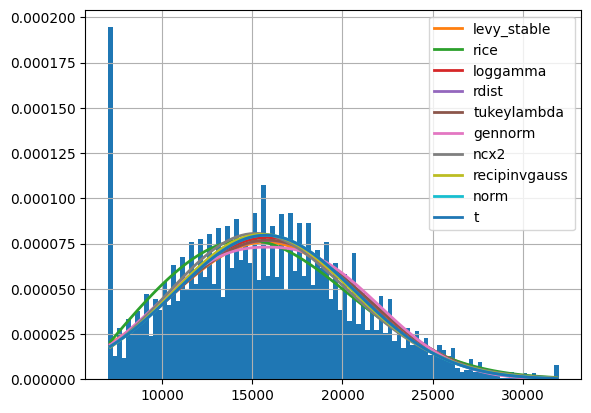

In [ ]:
fdp_VP = Fitter(df_delivery.valor_pedido)
fdp_VP.fit()
fdp_VP.summary(10)

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
burr,0.265081,20364.876932,20390.688831,0.136789,0.102687,1.680571e-43
mielke,0.276863,20838.925858,20864.737757,0.104859,0.059927,4.425340e-15
johnsonsb,0.291574,22853.405097,22879.216995,0.126964,0.056124,2.800706e-13
exponweib,0.298020,19748.782031,19774.593930,0.150355,0.107819,6.351538e-48
kappa4,0.299817,21976.645575,22002.457473,0.105813,0.059927,4.425340e-15
wrapcauchy,0.308219,22731.754265,22751.113189,0.107649,0.059843,4.868188e-15
bradford,0.313546,22780.179243,22799.538167,0.120917,0.077123,1.053811e-24
tukeylambda,0.314943,22744.927484,22764.286408,0.107670,0.059927,4.425340e-15
uniform,0.315473,22771.422957,22784.328906,0.107806,0.059927,4.425340e-15
gennorm,0.315473,22773.426385,22792.785309,0.107806,0.493815,0.000000e+00


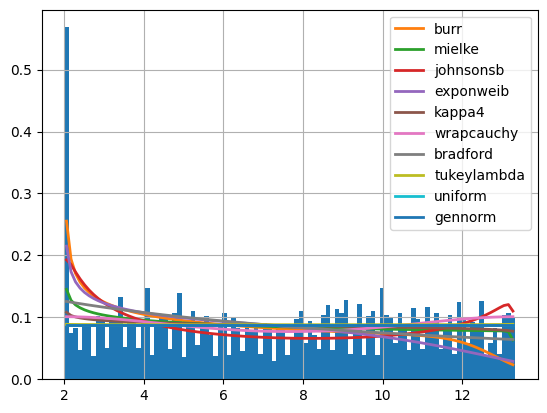

In [ ]:
fdp_TA = Fitter(df_delivery.TA_minutos)
fdp_TA.fit()
fdp_TA.summary(10)

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
betaprime,0.000509,30005.042513,30030.649643,0.013208,0.016347,0.182777
halfgennorm,0.000512,29993.160477,30012.365824,0.012538,0.012320,0.504375
burr12,0.000540,30014.593245,30040.200374,0.012548,0.012995,0.435661
weibull_min,0.000548,29951.649868,29970.855215,0.013144,0.013474,0.390198
gengamma,0.000548,29956.736920,29982.344049,0.013100,0.014629,0.293326
gamma,0.000594,29946.709390,29965.914737,0.014528,0.017011,0.150039
geninvgauss,0.000614,29997.976242,30023.583371,0.013439,0.015094,0.259467
genhyperbolic,0.000614,30000.066364,30032.075275,0.013460,0.014988,0.266899
erlang,0.000624,29942.980193,29962.185540,0.014347,0.018327,0.099064
mielke,0.000642,30093.692071,30119.299200,0.013328,0.019998,0.055939


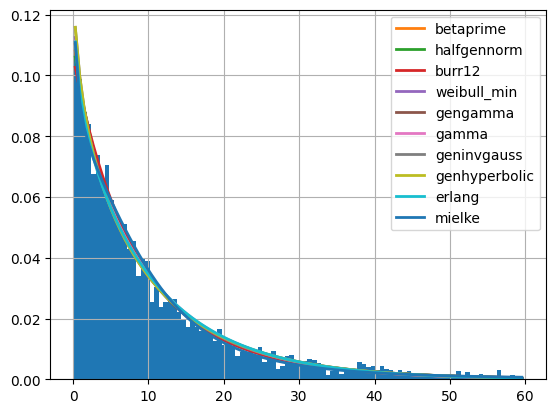

In [ ]:
fdp_IA = Fitter(histograma_IA.IA_minutos)
fdp_IA.fit()
fdp_IA.summary(10)

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
truncpareto,0.004498,2869.413585,2885.318989,0.843747,0.017249,0.999692
genhyperbolic,0.004551,2893.558235,2913.439990,0.700444,0.961929,0.000000
f,0.004562,2888.129952,2904.035355,0.696257,0.035947,0.674838
gamma,0.004564,2885.178049,2897.107101,0.698873,0.035718,0.682468
exponweib,0.004579,2886.906394,2902.811797,0.703262,0.029872,0.862846
weibull_min,0.004605,2888.638784,2900.567836,0.690907,0.037932,0.608446
gengamma,0.004652,2880.202661,2896.108064,0.687035,0.043375,0.436578
erlang,0.004664,2887.665045,2899.594098,0.684363,0.042593,0.459683
pearson3,0.004717,2888.066843,2899.995895,0.715026,0.031944,0.803951
betaprime,0.004762,2893.938298,2909.843702,0.668601,0.048609,0.299836


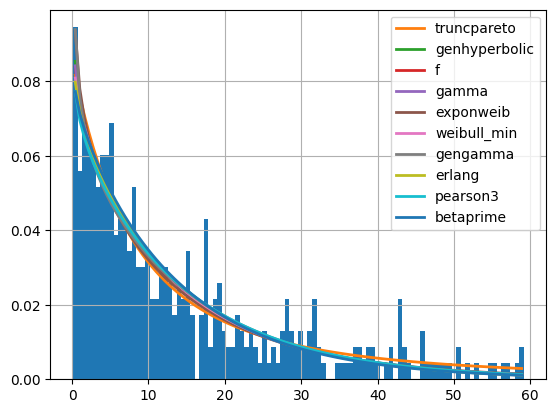

In [ ]:
fdp_IA_manana = Fitter(histograma_IA_manana.IA_minutos)
fdp_IA_manana.fit()
fdp_IA_manana.summary(10)

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
dpareto_lognorm,0.003198,6699.553981,6728.970437,0.234092,0.021913,0.717170
chi2,0.003398,6675.368066,6690.076294,0.230996,0.022044,0.710345
genhyperbolic,0.003399,6684.222402,6708.736115,0.235567,0.969849,0.000000
erlang,0.003402,6669.927539,6684.635767,0.236174,0.023368,0.640133
geninvgauss,0.003407,6677.567687,6697.178658,0.234928,0.023648,0.625217
gamma,0.003409,6669.088731,6683.796959,0.242099,0.023146,0.651929
mielke,0.003422,6711.052139,6730.663110,0.167041,0.053470,0.006510
gengamma,0.003447,6664.483474,6684.094445,0.234699,0.026377,0.484899
exponweib,0.003462,6678.134717,6697.745688,0.245043,0.020231,0.802243
pearson3,0.003484,6675.620228,6690.328457,0.239621,0.029728,0.336193


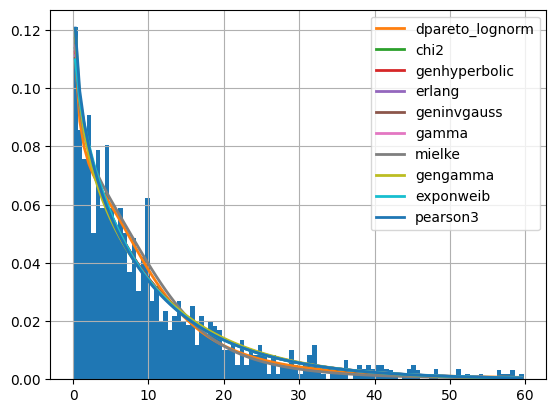

In [ ]:
fdp_IA_mediodia = Fitter(histograma_IA_mediodia.IA_minutos)
fdp_IA_mediodia.fit()
fdp_IA_mediodia.summary(10)

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
gengamma,0.002867,4856.419782,4874.601181,0.244220,0.030938,0.508090
burr12,0.002887,4874.726540,4892.907939,0.236201,0.035657,0.331219
weibull_min,0.002887,4853.345018,4866.981067,0.245723,0.029972,0.549122
geninvgauss,0.002889,4868.749928,4886.931326,0.248869,0.026859,0.686512
gamma,0.002979,4852.241608,4865.877657,0.212785,0.048381,0.074415
dpareto_lognorm,0.002985,4894.892450,4922.164548,0.236856,0.039804,0.214354
genhyperbolic,0.002988,4871.553600,4894.280349,0.248499,0.026994,0.680514
halfgennorm,0.003028,4871.691486,4885.327535,0.241954,0.032721,0.436221
ncx2,0.003102,4867.943686,4886.125085,0.191831,0.061816,0.009372
exponweib,0.003129,4858.378438,4876.559836,0.245873,0.029505,0.569342


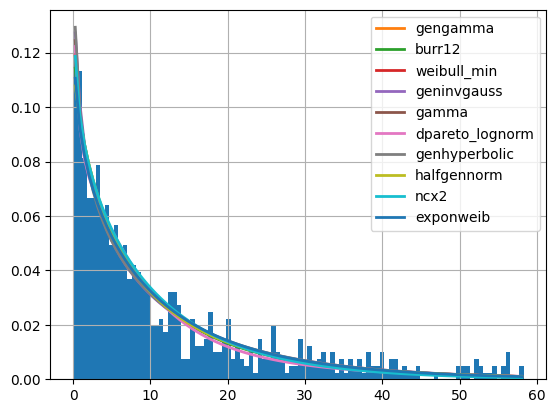

In [ ]:
fdp_IA_tarde = Fitter(histograma_IA_tarde.IA_minutos)
fdp_IA_tarde.fit()
fdp_IA_tarde.summary(10)

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
exponweib,0.000842,14042.375044,14065.167161,0.073263,0.008981,0.993606
halfgennorm,0.000843,14041.739886,14058.833973,0.076799,0.008300,0.997824
betaprime,0.000848,14043.946757,14066.738874,0.075687,0.008435,0.997245
burr12,0.000858,14041.897283,14064.689400,0.076702,0.009425,0.988628
pareto,0.000860,14044.247862,14061.341950,0.075713,0.010779,0.957518
gengamma,0.000876,14036.617915,14059.410032,0.075358,0.009411,0.988822
genpareto,0.000900,14060.832011,14077.926098,0.077245,0.012109,0.899082
truncpareto,0.000911,14031.280968,14054.073084,0.080856,0.015743,0.639617
weibull_min,0.000923,14028.338737,14045.432824,0.073227,0.011543,0.927376
geninvgauss,0.000948,14047.724023,14070.516140,0.074302,0.012017,0.904008


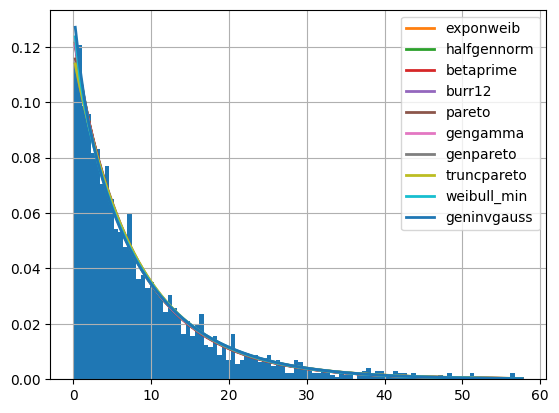

In [ ]:
fdp_IA_noche = Fitter(histograma_IA_noche.IA_minutos)
fdp_IA_noche.fit()
fdp_IA_noche.summary(10)

In [ ]:
fdp_VP.get_best(method = 'sumsquare_error')

{'levy_stable': {'alpha': np.float64(2.0),
  'beta': np.float64(1.0),
  'loc': np.float64(15741.906566619873),
  'scale': np.float64(3721.1740041928724)}}

In [ ]:
alpha = np.float64(2.0)
beta = np.float64(1.0)
loc = np.float64(15741.906566619873)
scale = np.float64(3721.1740041928724)

In [ ]:
fdp_VP_levy = stats.levy_stable.rvs(alpha=alpha,beta=beta,loc=loc,scale=scale,size=12000)

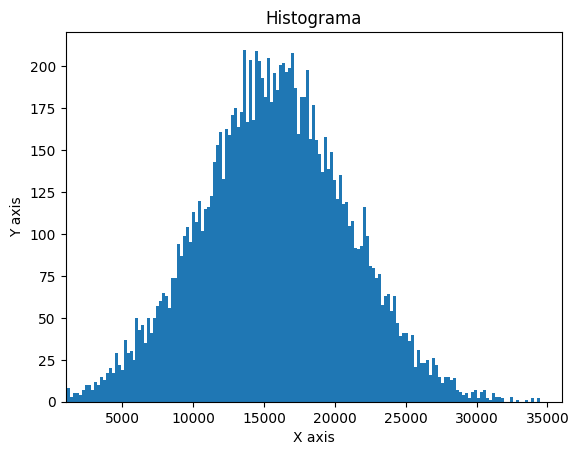

In [ ]:
plt.title("Histograma")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.xlim(1000,36000)
#plt.ylim(0,1300)
plt.hist(fdp_VP_levy, bins=200)
plt.show()

In [ ]:
fdp_TA.get_best(method = 'sumsquare_error')

{'burr': {'c': np.float64(19.651557454580033),
  'd': np.float64(0.038167911796393936),
  'loc': np.float64(1.9999999996448545),
  'scale': np.float64(10.948566708365782)}}

In [ ]:
a = np.float64(0.6400351082272648)
b = np.float64(3.291445952123444)
c = np.float64(-21.641630779133074)
z = np.float64(0.18368453258021916)
loc = np.float64(1.999999999999997)
scale = np.float64(21.199830239869726)

In [ ]:
fdp_TA_gausshyper = stats.gausshyper.rvs(a=a, b=b, c=c, z=z, loc=loc, scale=scale, size=15000)

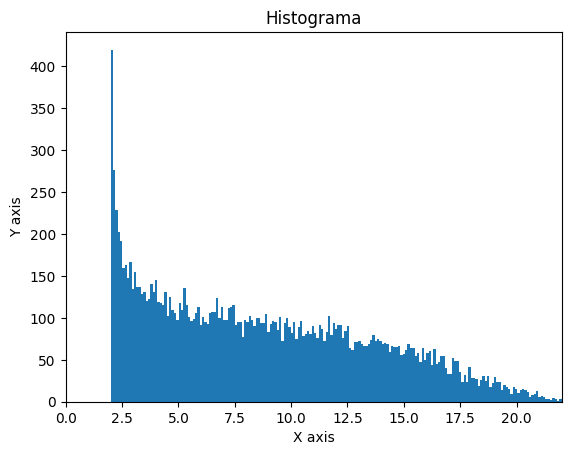

In [ ]:
plt.title("Histograma")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.xlim(0,22)
#plt.ylim(0,1300)
plt.hist(fdp_TA_gausshyper, bins=200)
plt.show()

In [ ]:
fdp_IA.get_best(method = 'sumsquare_error')

{'betaprime': {'a': np.float64(0.9501224490707898),
  'b': np.float64(15.623807241247015),
  'loc': np.float64(-0.0005544906779426833),
  'scale': np.float64(162.14906817742178)}}

In [ ]:
a = np.float64(0.9530134056313297)
b = np.float64(6.943339473955428)
loc= np.float64(-6.808893876682824e-12)
scale = np.float64(58.466567743807836)

In [ ]:
fdp_IA_betaprime = stats.betaprime.rvs(a,b,loc=loc,scale=scale,size=15000)

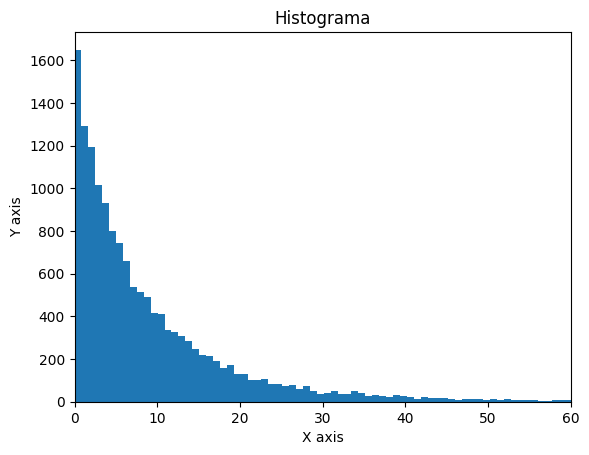

In [ ]:
plt.title("Histograma")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.xlim(0,60)
#plt.ylim(0,1300)
plt.hist(fdp_IA_betaprime, bins=200)
plt.show()

fdp mañana

In [ ]:
fdp_IA_manana.get_best(method = 'sumsquare_error')

{'truncpareto': {'b': np.float64(1.441697417283704),
  'c': np.float64(4.0004347998439265),
  'loc': -19.563814309980994,
  'scale': np.float64(19.680480976647658)}}

In [ ]:
b = np.float64(2.2551978138264284)
c = np.float64(3.327098109232383)
loc = -25.222206202645722
scale = np.float64(25.238872869312388)

In [ ]:
fdp_IA_manana_truncpareto = stats.truncpareto.rvs(b,c,loc=loc,scale=scale,size=15000)

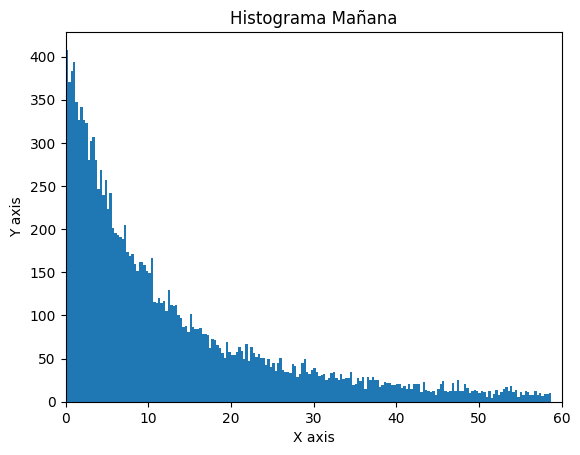

In [ ]:
plt.title("Histograma Mañana")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.xlim(0,60)
#plt.ylim(0,1300)
plt.hist(fdp_IA_manana_truncpareto, bins=200)
plt.show()

fdp mediodia

In [ ]:
fdp_IA_mediodia.get_best(method = 'sumsquare_error')

{'dpareto_lognorm': {'u': np.float64(1.7715759026063942),
  's': np.float64(0.459780144382509),
  'a': np.float64(1.7824568593140466),
  'b': np.float64(0.7889320460364995),
  'loc': np.float64(-8.639553285741703e-28),
  'scale': np.float64(1.9094455177533034)}}

In [ ]:
a = np.float64(0.932081706240188)
b = np.float64(12.90213366815335)
loc = np.float64(-7.211798797808576e-15)
scale = np.float64(118.81550086970424)

In [ ]:
fdp_IA_mediodia_betaprime = stats.betaprime.rvs(a,b,loc=loc,scale=scale,size=15000)

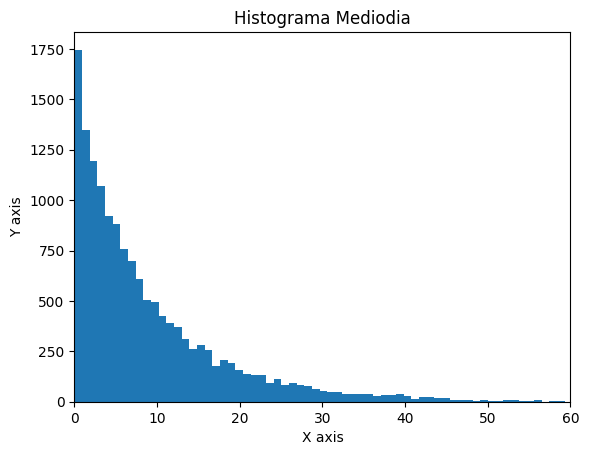

In [ ]:
plt.title("Histograma Mediodia")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.xlim(0,60)
#plt.ylim(0,1300)
plt.hist(fdp_IA_mediodia_betaprime, bins=200)
plt.show()

fdp tarde

In [ ]:
fdp_IA_tarde.get_best(method = 'sumsquare_error')

{'gengamma': {'a': np.float64(1.043646260063125),
  'c': np.float64(0.8440929419432228),
  'loc': np.float64(-3.448948824382853e-31),
  'scale': np.float64(10.665180425252503)}}

In [ ]:
a = np.float64(0.8786906483738385)
b = np.float64(2.8851477922498807)
loc = np.float64(-2.1062865154599568e-16)
scale = np.float64(27.190131073332147)

In [ ]:
fdp_IA_tarde_betaprime = stats.betaprime.rvs(a,b,loc=loc,scale=scale,size=15000)

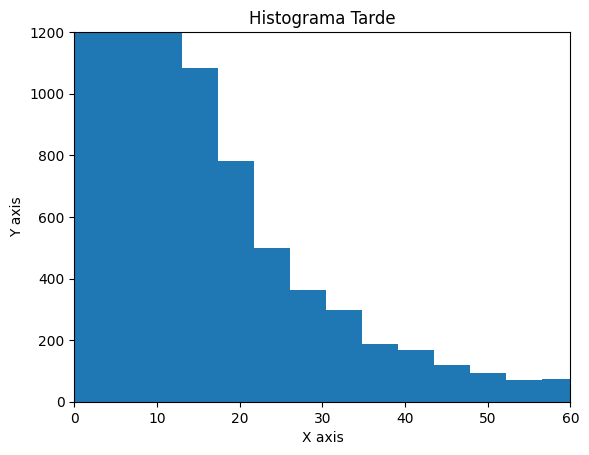

In [ ]:
plt.title("Histograma Tarde")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.xlim(0,60)
plt.ylim(0,1200)
plt.hist(fdp_IA_tarde_betaprime, bins=200)
plt.show()

fdp noche

In [ ]:
fdp_IA_noche.get_best(method = 'sumsquare_error')

{'exponweib': {'a': np.float64(1.0913245523817308),
  'c': np.float64(0.9120914422286006),
  'loc': np.float64(-2.2557443693762687e-31),
  'scale': np.float64(7.968566578027044)}}

In [ ]:
a = np.float64(1.314914115028272)
c = np.float64(0.8132275635917063)
loc = np.float64(-0.0009800860801003194)
scale = np.float64(5.506134922219468)

In [ ]:
fdp_IA_noche_exponweib = stats.exponweib.rvs(a,c,loc=loc,scale=scale,size=15000)

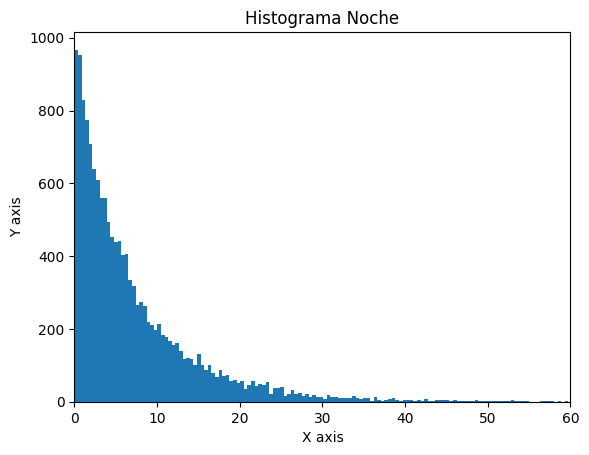

In [ ]:
plt.title("Histograma Noche")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.xlim(0,60)
#plt.ylim(0,1300)
plt.hist(fdp_IA_noche_exponweib, bins=200)
plt.show()